In [1]:
#Import Required Libraries

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.layers import Dense, MaxPool2D, Conv2D, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
#Perform Data Augmentation
# This code sets up an ImageDataGenerator object to generate new, diverse training samples
# by applying various transformations to the input images.

datagen = ImageDataGenerator(featurewise_center=False,
                             samplewise_center=False,
                             featurewise_std_normalization=False,
                             samplewise_std_normalization=False,
                             zca_whitening=False,
                             rotation_range=10,
                             zoom_range=0.1,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             horizontal_flip=False,
                             vertical_flip=False,
                             rescale=1/255.0, 
                             validation_split=0.2)

In [4]:
## Load the Xception model without the top (classification) layer
# This allows us to use the model as a feature extractor for our custom dataset
xception_wo_top = Xception(include_top=False, weights='imagenet', input_tensor=None, input_shape=(71,71,3), pooling=None)

In [5]:
# Generate training data using the ImageDataGenerator
trainDatagen = datagen.flow_from_directory(directory='C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\cell_images',
                                           target_size=(71,71),
                                           class_mode = 'binary',
                                           batch_size = 16,
                                           subset='training')

Found 22048 images belonging to 2 classes.


In [6]:
# Generate validation data using the ImageDataGenerator
valDatagen = datagen.flow_from_directory(directory='C:\\Users\\jains16\\Desktop\\ML Project\\archive\\cell_images\\cell_images',
                                           target_size=(71,71),
                                           class_mode = 'binary',
                                           batch_size = 16,
                                           subset='validation')

Found 5510 images belonging to 2 classes.


In [7]:

early_stop = EarlyStopping(monitor='val_loss',patience=5)

In [8]:
# Defining the architecture of the model

model = Sequential()
model.add(xception_wo_top)
model.add(GlobalAveragePooling2D(input_shape=(7,7,2048)))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dense(units=1))
model.add(Activation('sigmoid'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ ?                           │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │     0 (unbuilt) │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
history = model.fit(trainDatagen,
                   epochs =20,
                   validation_data = valDatagen,
                   callbacks=[early_stop])

Epoch 1/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 586s 410ms/step - accuracy: 0.9091 - loss: 0.2470 - val_accuracy: 0.9359 - val_loss: 0.2863
Epoch 2/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 573s 415ms/step - accuracy: 0.9558 - loss: 0.1381 - val_accuracy: 0.9510 - val_loss: 0.1642
Epoch 3/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 565s 410ms/step - accuracy: 0.9600 - loss: 0.1205 - val_accuracy: 0.9517 - val_loss: 0.1561
Epoch 4/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 561s 407ms/step - accuracy: 0.9635 - loss: 0.1129 - val_accuracy: 0.9367 - val_loss: 0.1770
Epoch 5/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 562s 408ms/step - accuracy: 0.9648 - loss: 0.1055 - val_accuracy: 0.9470 - val_loss: 0.1574
Epoch 6/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 565s 410ms/step - accuracy: 0.9684 - loss: 0.0960 - val_accuracy: 0.9443 - val_loss: 0.1870
Epoch 7/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 564s 409ms/step - accuracy: 0.9679 - loss: 0.0987 - val_accuracy: 0.9559 - val_loss: 0.1320
Epoch 8/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 570s 413ms/step - ac

In [12]:
import matplotlib.pyplot as plt

def plotLearningCurve(history, epochs):
    # Check if 'accuracy' is in the history and use 'acc' as a fallback (for older Keras versions)
    accuracy_key = 'accuracy' if 'accuracy' in history.history.keys() else 'acc'
    val_accuracy_key = 'val_accuracy' if 'val_accuracy' in history.history.keys() else 'val_acc'

    # Assuming the presence of 'accuracy' or 'acc' in the history
    if accuracy_key in history.history:
        plt.figure(figsize=(14, 5))

        # Subplot for accuracy
        plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
        plt.plot(history.history[accuracy_key], '-o', label='Training Accuracy')
        plt.plot(history.history[val_accuracy_key], '-o', label='Validation Accuracy')
        plt.title('Model Accuracy Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend(loc='lower right')
        plt.grid(True)  # Add gridlines

        # Subplot for loss
        plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
        plt.plot(history.history['loss'], '-o', label='Training Loss')
        plt.plot(history.history['val_loss'], '-o', label='Validation Loss')
        plt.title('Model Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(loc='upper right')
        plt.grid(True)  # Add gridlines

        # Layout setting to avoid tight layout issues
        plt.tight_layout()
        plt.show()
    else:
        print('The provided history object does not contain an accuracy entry.')

# Example usage:
# plotLearningCurve(history, 13)

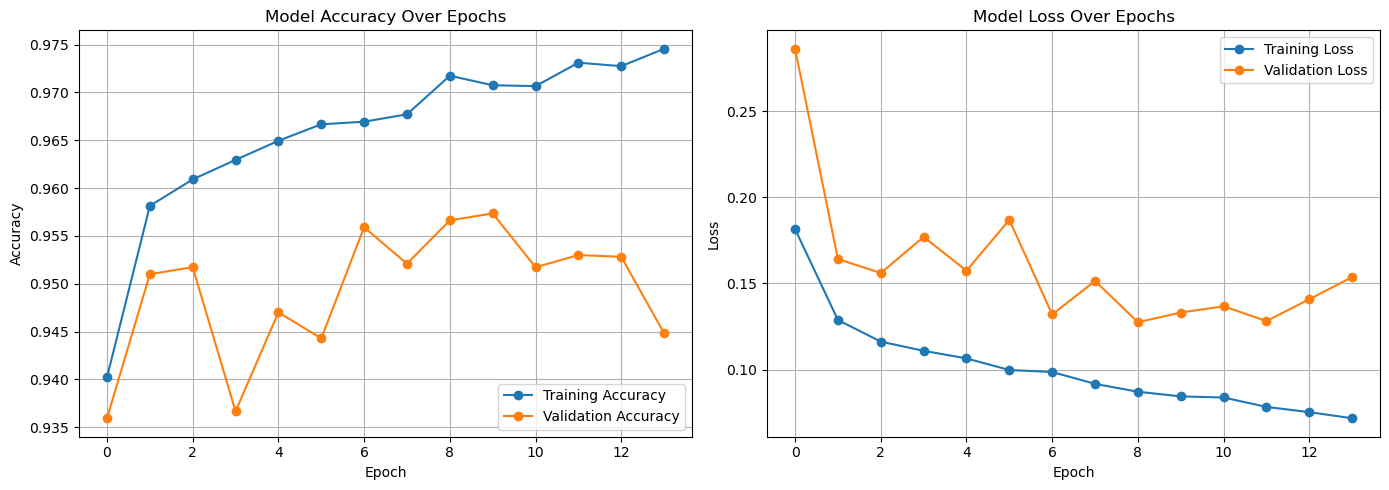

In [13]:
plotLearningCurve(history,13)

173/173 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step
              precision    recall  f1-score   support

 Parasitized       0.99      0.90      0.94      2755
  Uninfected       0.91      0.99      0.95      2755

    accuracy                           0.95      5510
   macro avg       0.95      0.95      0.95      5510
weighted avg       0.95      0.95      0.95      5510



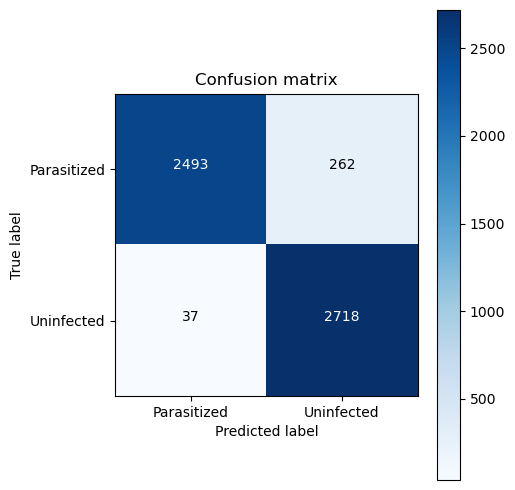

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# First, we need to generate all the batches of validation data
val_datagen_batches = valDatagen
val_datagen_batches.reset() # To ensure we start from the beginning
val_images, val_labels = next(val_datagen_batches)
for _ in range(1, val_datagen_batches.__len__()):
    imgs, lbls = next(val_datagen_batches)
    val_images = np.concatenate((val_images, imgs))
    val_labels = np.concatenate((val_labels, lbls))

# Now, we predict the classes using the model
val_preds = model.predict(val_images)
val_preds = (val_preds > 0.5).astype('int')

# Calculate precision, recall, and F1 score
print(classification_report(val_labels, val_preds, target_names=list(trainDatagen.class_indices.keys())))

# Calculate confusion matrix
conf_matrix = confusion_matrix(val_labels, val_preds)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plt.figure(figsize=(5, 5))
plot_confusion_matrix(conf_matrix, classes=list(trainDatagen.class_indices.keys()))
plt.show()

In [15]:
# Inspired By - https://www.kaggle.com/code/kahansheth/detection-of-malaria-using-tl-95-68